# 11 — Felanalys: vilka bilder har 3-klassmodellen svårt för?
Kör den tränade modellen på valideringsdatan, hittar felklassificerade bilder, och visar dem grupperade efter feltyp (t.ex. epic→thin, medium→epic) så vi kan se mönster, inte bara siffror.

In [ ]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

SEED = 42
DATA_DIR   = 'data/epic_dataset'
IMG_SIZE   = (178, 178)
BATCH_SIZE = 32
MODEL_PATH = 'models/epic_detector_3class_3.keras'

model = tf.keras.models.load_model(MODEL_PATH)

# VIKTIGT: shuffle=True (standard, som träningsnotebooken) avgör VILKA filer som
# hamnar i valideringsdelen, inte bara ordningen — shuffle=False ger en helt
# annan filmängd (testat: bara 135/643 gemensamma filer mellan de två lägena!).
# Måste matcha träningens inställning exakt, annars läcker träningsbilder in
# i "valideringen" och resultatet blir konstgjort bättre.
val_ds_for_filelist = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset='validation',
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

class_names = val_ds_for_filelist.class_names
file_paths = val_ds_for_filelist.file_paths
print('Klasser:', class_names)
print(f'{len(file_paths)} valideringsbilder (korrekt filmängd, matchar träningen).')

## Kör modellen på all valideringsdata
Sparar sanning, prediktion och sannolikheter per bild, ihopkopplat med filsökvägen.

In [ ]:
y_true = []
y_pred = []
all_probs = []

for path in file_paths:
    # Robust mot nästlade undermappar (t.ex. epic_dataset/epic/pinterest_mustaches/x.jpg) —
    # tar den FÖRSTA mappkomponenten efter DATA_DIR, inte närmaste förälder.
    rel = os.path.relpath(path, DATA_DIR)
    true_cls_name = rel.split(os.sep)[0]
    y_true.append(class_names.index(true_cls_name))

    img = tf.keras.utils.load_img(path, target_size=IMG_SIZE)
    arr = np.expand_dims(np.array(img), axis=0).astype('float32')
    preds = model.predict(arr, verbose=0)[0]

    y_pred.append(int(np.argmax(preds)))
    all_probs.append(preds)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
all_probs = np.array(all_probs)

assert len(file_paths) == len(y_true), 'Mismatch — kontrollera filmängden.'

from collections import Counter
print('Sann klassfördelning:', Counter([class_names[i] for i in y_true]))

misclassified_idx = np.where(y_true != y_pred)[0]
print(f'{len(misclassified_idx)} av {len(y_true)} felklassificerade ({len(misclassified_idx)/len(y_true)*100:.1f}%).')

## Gruppera felen efter typ
T.ex. "epic→thin" eller "medium→epic" — visar vilka feltyper som är vanligast.

In [37]:
from collections import Counter

error_types = Counter()
for idx in misclassified_idx:
    true_name = class_names[y_true[idx]]
    pred_name = class_names[y_pred[idx]]
    error_types[f'{true_name} → {pred_name}'] += 1

for error_type, count in error_types.most_common():
    print(f'{error_type}: {count}')

thin → medium: 21


## Aktuell confusion matrix (denna modell, denna körning)
Genererad direkt här så den garanterat matchar felanalysen nedan — inte en gammal skärmdump från en annan träningsomgång.

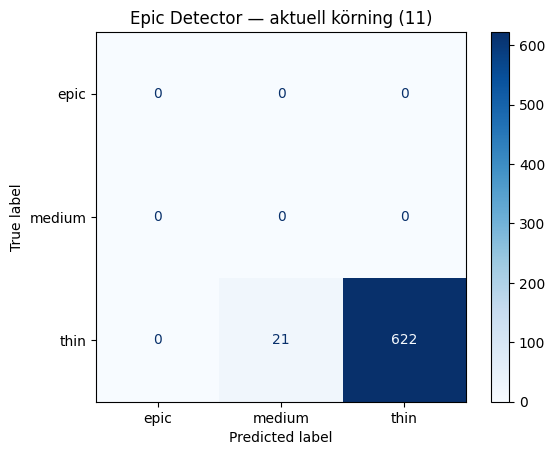

epic: 0/0 korrekt (0.0%)
medium: 0/0 korrekt (0.0%)
thin: 622/643 korrekt (96.7%)


In [38]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_true, y_pred, labels=range(len(class_names)))
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
disp.plot(values_format='d', cmap='Blues')
plt.title('Epic Detector — aktuell körning (11)')
plt.show()

for i, true_name in enumerate(class_names):
    total = cm[i].sum()
    correct = cm[i][i]
    pct = (correct / total * 100) if total > 0 else 0.0
    print(f'{true_name}: {correct}/{total} korrekt ({pct:.1f}%)')

## Visa bilderna för en specifik feltyp
Ändra `TARGET_ERROR` till t.ex. `'medium → epic'` eller `'epic → thin'` för att granska just den typen av fel visuellt.

In [39]:
TARGET_ERROR = 'medium → thin'  # ändra till feltypen du vill granska
MAX_IMAGES = 40  # höj om du vill se fler än standardgränsen

true_cls, pred_cls = TARGET_ERROR.split(' → ')
true_idx, pred_idx = class_names.index(true_cls), class_names.index(pred_cls)

matching = [
    idx for idx in misclassified_idx
    if y_true[idx] == true_idx and y_pred[idx] == pred_idx
]

print(f'{len(matching)} bilder med felet "{TARGET_ERROR}".')

if len(matching) == 0:
    print('Inga bilder att visa — välj en annan TARGET_ERROR (se listan i förra cellen).')
else:
    n = min(len(matching), MAX_IMAGES)
    cols = 4
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = np.array(axes).flatten()  # funkar oavsett om n=1 eller fler

    for ax, idx in zip(axes, matching[:n]):
        img = tf.keras.utils.load_img(file_paths[idx], target_size=IMG_SIZE)
        probs = all_probs[idx]
        ax.imshow(img)
        ax.set_title(
            f'{os.path.basename(file_paths[idx])}\n'
            f'epic={probs[class_names.index("epic")]:.2f} '
            f'med={probs[class_names.index("medium")]:.2f} '
            f'thin={probs[class_names.index("thin")]:.2f}',
            fontsize=9
        )
        ax.axis('off')

    for ax in axes[n:]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()

0 bilder med felet "medium → thin".
Inga bilder att visa — välj en annan TARGET_ERROR (se listan i förra cellen).


## Nästa steg
Byt `TARGET_ERROR` ovan och kör om för att gå igenom alla feltyper en i taget — särskilt intressant just nu: `medium → epic`, `medium → thin`, `epic → thin` och `thin → epic` (de farligaste extremfallen).

## Grad-CAM — var tittar modellen?
Testar hypotesen att modellen reagerar på **totalt ansiktshår** (skägg+mustasch) istället för specifikt mustaschen, för `medium → epic`-fallen. Skriver ut filnamn/sökväg så du hittar bilden på disk.

In [ ]:
import matplotlib.cm as cm

def find_last_conv_layer(model):
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            return layer.name
    raise ValueError('Inget Conv2D-lager hittat.')


def grad_cam(model, img_array, class_idx, layer_name):
    """Manuell lager-för-lager forward pass — robust mot Sequential-modeller
    med nästlade data-augmentation-lager (vanliga Functional-API-extraktioner
    kraschar ofta på sådana modeller)."""
    layer_outputs = []
    x = img_array
    target_output = None

    for layer in model.layers:
        x = layer(x, training=False)
        if layer.name == layer_name:
            target_output = x

    with tf.GradientTape() as tape:
        x = img_array
        conv_output = None
        for layer in model.layers:
            x = layer(x, training=False)
            if layer.name == layer_name:
                conv_output = x
                tape.watch(conv_output)
        predictions = x
        loss = predictions[:, class_idx]

    grads = tape.gradient(loss, conv_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_output = conv_output[0]
    heatmap = conv_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()


def overlay_heatmap(img, heatmap, alpha=0.4):
    heatmap_resized = np.array(Image.fromarray(np.uint8(255 * heatmap)).resize(img.size))
    colored = cm.jet(heatmap_resized)[:, :, :3]
    colored = np.uint8(255 * colored)
    overlay = np.uint8(np.array(img) * (1 - alpha) + colored * alpha)
    return Image.fromarray(overlay)


from PIL import Image

last_conv = find_last_conv_layer(model)
print('Sista Conv2D-lagret:', last_conv)

epic_idx = class_names.index('epic')

# Tar de tre första bilderna från det senast visade TARGET_ERROR (matching).
for idx in matching[:3]:
    path = file_paths[idx]
    print(f'\nFil: {os.path.basename(path)}')
    print(f'Sökväg: {path}')
    probs = all_probs[idx]
    print(f'epic={probs[epic_idx]:.2f} med={probs[class_names.index("medium")]:.2f} thin={probs[class_names.index("thin")]:.2f}')

    img = Image.open(path).convert('RGB').resize(IMG_SIZE)
    img_array = np.expand_dims(np.array(img), axis=0).astype('float32')

    heatmap = grad_cam(model, img_array, epic_idx, last_conv)
    overlay = overlay_heatmap(img, heatmap)

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(img)
    axes[0].set_title('Original')
    axes[0].axis('off')
    axes[1].imshow(overlay)
    axes[1].set_title('Grad-CAM (epic)')
    axes[1].axis('off')
    plt.show()

## Är felklassificerade bilder lågupplösta/suddiga?
Mäter skärpa (Laplacian-varians — lägre = suddigare) och ursprunglig filstorlek för felklassificerade vs korrekt klassificerade bilder.

In [ ]:
import cv2
import random

def sharpness_score(path):
    """Laplacian-varians — standardmått för hur suddig en bild är. Lägre = suddigare."""
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None
    return cv2.Laplacian(img, cv2.CV_64F).var()


def file_size_kb(path):
    return os.path.getsize(path) / 1024


# Felklassificerade bilder (från senast körda TARGET_ERROR)
error_sharpness = []
error_filesize = []
for idx in matching:
    path = file_paths[idx]
    s = sharpness_score(path)
    if s is not None:
        error_sharpness.append(s)
        error_filesize.append(file_size_kb(path))

# Slumpmässigt sample av KORREKT klassificerade bilder att jämföra mot
correct_idx = np.where(y_true == y_pred)[0]
sample_correct_idx = random.sample(list(correct_idx), min(100, len(correct_idx)))

correct_sharpness = []
correct_filesize = []
for idx in sample_correct_idx:
    path = file_paths[idx]
    s = sharpness_score(path)
    if s is not None:
        correct_sharpness.append(s)
        correct_filesize.append(file_size_kb(path))

print(f'FELKLASSIFICERADE ({len(error_sharpness)} bilder):')
print(f'  Medelskärpa: {np.mean(error_sharpness):.1f} (median: {np.median(error_sharpness):.1f})')
print(f'  Medelfilstorlek: {np.mean(error_filesize):.1f} KB (median: {np.median(error_filesize):.1f})')

print(f'\nKORREKT KLASSIFICERADE, sample ({len(correct_sharpness)} bilder):')
print(f'  Medelskärpa: {np.mean(correct_sharpness):.1f} (median: {np.median(correct_sharpness):.1f})')
print(f'  Medelfilstorlek: {np.mean(correct_filesize):.1f} KB (median: {np.median(correct_filesize):.1f})')

## Grad-CAM på mustasch-DETEKTORN (binär modell)
För fall där `mustache_detector_3.keras` är väldigt säker på "ingen mustasch" trots en synlig (om än fjunig) mustasch. Återanvänder `find_last_conv_layer`/`grad_cam`/`overlay_heatmap` från tidigare, men laddar den binära modellen och använder klassindex 0 (den enda outputen).

In [ ]:
from facenet_pytorch import MTCNN

mustache_model = tf.keras.models.load_model('models/mustache_detector_3.keras')
mustache_last_conv = find_last_conv_layer(mustache_model)
print('Sista Conv2D-lagret (mustasch-modell):', mustache_last_conv)

mtcnn_178 = MTCNN(image_size=178, margin=40, post_process=False)

PROBLEM_IMAGE_PATH = 'data/reference_test_images/bäckis.jpg'

original = Image.open(PROBLEM_IMAGE_PATH).convert('RGB')

face = mtcnn_178(original)
if face is None:
    print('MTCNN hittade inget ansikte i bilden!')
else:
    img = Image.fromarray(face.permute(1, 2, 0).numpy().astype('uint8'))
    img_array = np.expand_dims(np.array(img), axis=0).astype('float32')

    mustache_prob = float(mustache_model.predict(img_array, verbose=0)[0][0])
    print(f'mustache_prob: {mustache_prob:.4f}')

    heatmap = grad_cam(mustache_model, img_array, class_idx=0, layer_name=mustache_last_conv)
    overlay = overlay_heatmap(img, heatmap)

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(img)
    axes[0].set_title('Croppat ansikte (det modellen faktiskt ser)')
    axes[0].axis('off')
    axes[1].imshow(overlay)
    axes[1].set_title(f'Grad-CAM (mustache_prob={mustache_prob:.3f})')
    axes[1].axis('off')
    plt.show()